# PhysREVE — Seizure Detection Quick Wins (CHB-MIT)

Same pipeline as `seizure_notebook.ipynb` with four additions:

| New Section | What it tests |
|---|---|
| **ML Baselines** | Band-power LDA/LogReg — AUC + sensitivity |
| **Base REVE** | MAE-only pretrain — does physics help over plain MAE? |
| **Linear Probe** | Are pretrained reps better than random for seizure? |
| **Small Model** | d=64, 2 layers — right-sized for small seizure datasets |


In [1]:
import subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    repo = '/content/PhysREVE'
    if not os.path.exists(repo):
        subprocess.check_call(['git', 'clone', '-q', 'https://github.com/UgoBruzadin/PhysREVE.git', repo])
    else:
        subprocess.check_call(['git', '-C', repo, 'pull', '-q'])
    if repo not in sys.path:
        sys.path.insert(0, repo)
    # Colab already ships torch, numpy, scipy, sklearn, matplotlib, seaborn, tqdm, requests
    # Install only what's missing
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mne>=1.6', 'moabb>=1.0', 'xgboost'])
    print('Colab environment ready.')
else:
    print('Local environment — ensure you ran: pip install -e .')

Colab environment ready.


In [2]:
# ── 1. Imports & setup ───────────────────────────────────────────────────────
import sys, os, warnings
sys.path.insert(0, '.')   # physreve package lives in the same directory

import numpy as np
import torch
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
)
warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')
print(f'MNE     : {mne.__version__}')


Device  : cuda
PyTorch : 2.10.0+cu128
MNE     : 1.12.0


## 1  Download CHB-MIT (Patient chb01)

We download only the 7 files that contain seizures plus 2 seizure-free files
for the unlabelled pretraining corpus.  Total ≈ 350 MB — cached after first run.


In [3]:
from physreve.datasets.chbmit import download_patient, parse_summary

DATA_DIR    = './data/chb-mit'
PATIENT_ID  = 'chb01'

# Files that contain seizures (chb01 has 7 seizures across these files)
SEIZURE_FILES = [
    'chb01_03.edf',  # seizure 2996-3036 s
    'chb01_04.edf',  # seizure 1467-1494 s
    'chb01_15.edf',  # seizure 1732-1772 s
    'chb01_16.edf',  # seizure 1015-1066 s
    'chb01_18.edf',  # seizure 1720-1810 s
    'chb01_21.edf',  # seizure  327-420  s
    'chb01_26.edf',  # seizure 1862-1963 s
]

# Extra seizure-free files for pretraining interictal pool
PRETRAIN_FILES = [
    'chb01_01.edf',
    'chb01_02.edf',
]

print('Downloading CHB-MIT patient 1...')
download_patient(
    patient_id=PATIENT_ID,
    data_dir=DATA_DIR,
    files=SEIZURE_FILES + PRETRAIN_FILES,
)
print('\nAll files ready.')


chb01-summary.txt:   0%|          | 0.00/5.36k [00:00<?, ?B/s]

Summary downloaded: data/chb-mit/chb01/chb01-summary.txt


chb01_03.edf:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

chb01_04.edf:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

chb01_15.edf:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

...

chb01_21.edf:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

chb01_26.edf:   0%|          | 0.00/27.4M [00:00<?, ?B/s]

chb01_01.edf:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

chb01_02.edf:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

Downloaded 9 EDF file(s) to data/chb-mit/chb01/

All files ready.


## 2  Parse Seizure Annotations & Window Data

In [4]:
from physreve.datasets.chbmit import parse_summary, load_patient_epochs
from pathlib import Path

summary_path = Path(DATA_DIR) / PATIENT_ID / f'{PATIENT_ID}-summary.txt'
seizure_info = parse_summary(str(summary_path))

print('Seizure annotations:')
for fname, seiz in seizure_info.items():
    if seiz:
        for s, e in seiz:
            print(f'  {fname}: {s}–{e} s  ({e-s} s duration)')


Seizure annotations:
  chb01_03.edf: 2996–3036 s  (40 s duration)
  chb01_04.edf: 1467–1494 s  (27 s duration)
  chb01_15.edf: 1732–1772 s  (40 s duration)
  chb01_16.edf: 1015–1066 s  (51 s duration)
  chb01_18.edf: 1720–1810 s  (90 s duration)
  chb01_21.edf: 327–420 s  (93 s duration)
  chb01_26.edf: 1862–1963 s  (101 s duration)


In [5]:
# Extract 4-second windows at 200 Hz
# Ictal:       within seizure (with 2 s buffer at boundaries)
# Interictal:  >= 60 s from any seizure

ictal_X, interictal_X, ch_names = load_patient_epochs(
    data_dir=DATA_DIR,
    patient_id=PATIENT_ID,
    seizure_info=seizure_info,
    window_sec=4.0,
    stride_sec=2.0,
    target_sfreq=200.0,
    ictal_buffer_sec=2.0,
    interictal_gap_sec=60.0,
    max_interictal_per_file=300,
    verbose=True,
)

N_CH  = ictal_X.shape[1]
T_WIN = ictal_X.shape[2]   # 800 samples = 4 s at 200 Hz
print(f'\nChannels ({N_CH}): {ch_names}')
print(f'Window   : {T_WIN} samples ({T_WIN/200:.1f} s at 200 Hz)')


  chb01_01.edf: 0 seizure(s), 0 ictal / 300 interictal windows total
  chb01_02.edf: 0 seizure(s), 0 ictal / 600 interictal windows total
  chb01_03.edf: 1 seizure(s), 17 ictal / 900 interictal windows total
  chb01_04.edf: 1 seizure(s), 27 ictal / 1200 interictal windows total
  chb01_15.edf: 1 seizure(s), 44 ictal / 1500 interictal windows total
  chb01_16.edf: 1 seizure(s), 66 ictal / 1800 interictal windows total
  chb01_18.edf: 1 seizure(s), 108 ictal / 2100 interictal windows total
  chb01_21.edf: 1 seizure(s), 151 ictal / 2400 interictal windows total
  chb01_26.edf: 1 seizure(s), 198 ictal / 2700 interictal windows total

Data extracted:
  Ictal (seizure)     :   198 windows  × (23 ch, 800 samples)
  Interictal (normal) :  2700 windows

Channels (23): ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Window  

## 3  Build Bipolar Leadfield

CHB-MIT uses a **bipolar montage** (e.g. "FP1-F7").
For the physics forward model:

$$L_{bip}[i, j] = L_{ref}[e_{1,i}, j] - L_{ref}[e_{2,i}, j]$$

where $L_{ref}$ is the standard referential leadfield for the underlying electrodes.


In [6]:
from physreve.datasets.chbmit import build_leadfield_bipolar

print(f'Building bipolar leadfield for {N_CH} channels...')
L_col_np, L_row_np, src_pos_np, info_ref, elec_xyz_np, valid_mask = \
    build_leadfield_bipolar(ch_names, sfreq=200.0, grid_pos=10.0, verbose=True)

N_SRC = L_col_np.shape[1]
print(f'\nLeadfield ready:')
print(f'  Channels × Sources : {L_col_np.shape}')
print(f'  Channels with valid bipolar mapping: {sum(valid_mask)}/{len(valid_mask)}')

# Move to device
L_col    = torch.tensor(L_col_np,    dtype=torch.float32).to(device)
L_row    = torch.tensor(L_row_np,    dtype=torch.float32).to(device)
ELEC_XYZ = torch.tensor(elec_xyz_np, dtype=torch.float32).to(device)  # (N_CH, 3)


Building bipolar leadfield for 23 channels...
  Unique electrodes: ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'FT10', 'FT9', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8']
  Source space: 2229 active dipoles
  Leadfield shape: (21, 2229)
  Bipolar leadfield: 23/23 channels mapped
  L_bip shape: (23, 2229)

Leadfield ready:
  Channels × Sources : (23, 2229)
  Channels with valid bipolar mapping: 23/23


## 4  Datasets & DataLoaders

In [7]:
from physreve.datasets.chbmit import make_seizure_loaders

pretrain_loader, train_loader, val_loader, test_loader = make_seizure_loaders(
    ictal_X, interictal_X,
    train_frac=0.70,
    val_frac=0.15,
    batch_size=16,
    seed=SEED,
    balance=True,
)

CLASS_NAMES = ['Interictal', 'Ictal']



Loaders built:
  Pretrain (interictal, unlabeled): 2700 windows
  Train : 278 | Val: 59 | Test: 59
  Class balance — ictal: 198, interictal: 198


## 2b  ML Baselines (AUC + Sensitivity)

For seizure detection, accuracy alone is misleading — predicting all-interictal scores high.  
Report AUC and sensitivity (seizure recall) as primary metrics.

In [8]:
from physreve import extract_features
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Numpy arrays for ML
X_tr_np  = train_loader.dataset.X.numpy()
y_tr_np  = train_loader.dataset.y.numpy()
X_val_np = val_loader.dataset.X.numpy()
y_val_np = val_loader.dataset.y.numpy()

feats_tr  = extract_features(X_tr_np,  sfreq=200.0)
feats_val = extract_features(X_val_np, sfreq=200.0)
print(f'Features: train {feats_tr.shape}, val {feats_val.shape}')
print(f'Class balance: train ictal={y_tr_np.sum()}/{len(y_tr_np)}  val ictal={y_val_np.sum()}/{len(y_val_np)}')

def eval_ml(clf, name):
    clf.fit(feats_tr, y_tr_np)
    preds = clf.predict(feats_val)
    proba = clf.predict_proba(feats_val)[:, 1]
    acc  = (preds == y_val_np).mean()
    sens = ((preds == 1) & (y_val_np == 1)).sum() / max((y_val_np == 1).sum(), 1)
    spec = ((preds == 0) & (y_val_np == 0)).sum() / max((y_val_np == 0).sum(), 1)
    auc  = roc_auc_score(y_val_np, proba)
    print(f'  {name:<12}  acc={acc:.3f}  sens={sens:.3f}  spec={spec:.3f}  AUC={auc:.3f}')
    return {'acc': acc, 'sens': sens, 'spec': spec, 'auc': auc}

print('ML Baselines:')
ml_sz = {}
ml_sz['lda']    = eval_ml(LinearDiscriminantAnalysis(), 'lda')
ml_sz['logreg'] = eval_ml(LogisticRegression(max_iter=1000, C=1.0), 'logreg')
try:
    from xgboost import XGBClassifier
    ml_sz['xgboost'] = eval_ml(
        XGBClassifier(n_estimators=100, verbosity=0, eval_metric='logloss'), 'xgboost')
except ImportError:
    print('  xgboost not available')


Features: train (278, 161), val (59, 161)
Class balance: train ictal=80/278  val ictal=59/59
ML Baselines:
  lda           acc=0.847  sens=0.847  spec=0.000  AUC=nan
  logreg        acc=0.966  sens=0.966  spec=0.000  AUC=nan
  xgboost       acc=0.746  sens=0.746  spec=0.000  AUC=nan


## 5  PhysREVE Configuration

We use a **smaller architecture** than the BCI IV 2a notebook — the labelled
dataset (few hundred windows) is much smaller than a large motor-imagery corpus.
Regularisation (`dropout=0.25`) and shorter pretraining keep the model from
over-parameterising the limited data.

`d_pos_x + d_pos_y + d_pos_z + d_pos_t` must equal `d_model`.


In [9]:
from physreve import PhysREVEConfig

CFG = PhysREVEConfig(
    # Smaller transformer — limited labelled data
    d_model      = 128,
    n_heads      = 4,
    n_layers     = 6,
    d_ff         = 512,
    dropout      = 0.25,

    # 50 samples/patch = 0.25 s at 200 Hz
    patch_size   = 50,
    mask_ratio   = 0.75,
    block_t      = 4,
    block_c      = 2,

    n_sources    = N_SRC,

    # Physics weights — keep physics loss; disable asymmetry (not applicable)
    lambda_phys  = 0.15,
    lambda_snr   = 0.05,
    lambda_asym  = 0.0,      # disabled

    leadfield_bias_scale = 0.5,

    # 4D pos enc: 32 × 4 = 128 = d_model
    d_pos_x      = 32,
    d_pos_y      = 32,
    d_pos_z      = 32,
    d_pos_t      = 32,

    exp_name     = '_seizure_chbmit',
)

# Number of patches per window (for block mask)
N_PATCHES = T_WIN // CFG.patch_size
print(f'Config OK: d_model={CFG.d_model}, n_layers={CFG.n_layers}')
print(f'Patches per window: {N_PATCHES}  ({CFG.patch_size} samples each)')
print(f'n_sources (actual from leadfield): {N_SRC}')


Config OK: d_model=128, n_layers=6
Patches per window: 16  (50 samples each)
n_sources (actual from leadfield): 2229


## 6  Phase 1 — Pretraining (Physics-Informed MAE)

Pretrain on **unlabelled interictal** windows.  The model learns general EEG
representations with MAE + physics consistency, without seeing any seizure labels.


In [10]:
from physreve.train import run_pretraining

print('='*60)
print('PHASE 1: Pretraining on unlabelled interictal EEG')
print('='*60)

pretrained_model, pretrain_hist = run_pretraining(
    cfg       = CFG,
    loader    = pretrain_loader,
    L_row     = L_row,
    L_col     = L_col,
    elec_xyz  = ELEC_XYZ,
    device    = device,
    n_epochs  = 20,
    lr        = 3e-4,
    sfreq     = 200.0,
    save_path = f'physreve_pretrained{CFG.exp_name}.pt',
)


PHASE 1: Pretraining on unlabelled interictal EEG
Pretraining PhysREVE — 2,585,448 parameters
Epochs: 20  |  Batches/epoch: 168
Losses: MAE + 0.15·L_phys + 0.05·L_snr
  Ep   1/20  L_mae=1.1321  L_phys=0.0858  L_snr=1.8783  L_total=1.2389  lr=6.00e-05
  Ep   5/20  L_mae=0.9799  L_phys=0.0698  L_snr=0.8238  L_total=1.0316  lr=3.00e-04
  Ep  10/20  L_mae=0.9780  L_phys=0.0639  L_snr=0.7475  L_total=1.0250  lr=2.25e-04
  Ep  15/20  L_mae=0.9774  L_phys=0.0620  L_snr=0.7163  L_total=1.0225  lr=7.50e-05
  Ep  20/20  L_mae=0.9770  L_phys=0.0612  L_snr=0.7024  L_total=1.0213  lr=0.00e+00
Pretrained weights saved: physreve_pretrained_seizure_chbmit.pt


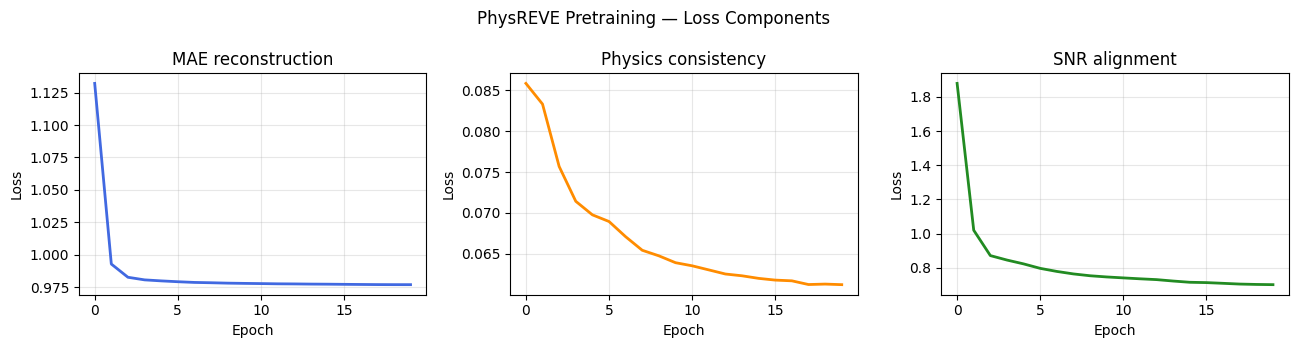

In [11]:
# ── Pretraining loss curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
fig.suptitle('PhysREVE Pretraining — Loss Components', fontsize=12)

for ax, key, label, color in zip(
    axes,
    ['mae', 'phys', 'snr'],
    ['MAE reconstruction', 'Physics consistency', 'SNR alignment'],
    ['royalblue', 'darkorange', 'forestgreen'],
):
    ax.plot(pretrain_hist[key], color=color, lw=2)
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'pretrain_losses{CFG.exp_name}.png', dpi=150)
plt.show()


## 7  Phase 2 — Fine-Tuning for Seizure Detection

Fine-tune with:
- **2 output classes** (interictal / ictal)
- **No asymmetry loss** (`lh_idx=None`)
- Differential LR: frozen encoder for 5 epochs, then unfrozen


In [12]:
from physreve.train import run_finetuning, run_baseline_finetune

print('='*60)
print('PHASE 2a: Baseline (random init, no pretraining)')
print('='*60)

model_base, hist_base = run_baseline_finetune(
    cfg          = CFG,
    train_loader = train_loader,
    val_loader   = val_loader,
    L_row        = L_row,
    L_col        = L_col,
    elec_xyz     = ELEC_XYZ,
    device       = device,
    n_classes    = 2,
    n_epochs     = 30,
    lr           = 3e-4,
    lh_idx       = None,   # no asymmetry loss
    rh_idx       = None,
)


PHASE 2a: Baseline (random init, no pretraining)
Fine-tuning PhysREVE (2 classes)
LR: encoder=0.0003  head=0.0003  freeze_warmup=0 epochs
Losses: CE + L_phys disabled (small dataset) + disabled
  [Epoch 1] Encoder unfrozen
  Ep   1/30  train=0.735  val=0.932  ce=0.593  phys=0.0868  asym=0.0000
  Ep  10/30  train=0.985  val=0.729  ce=0.224  phys=0.0870  asym=0.0000
  Ep  20/30  train=0.996  val=0.864  ce=0.206  phys=0.0869  asym=0.0000
  Ep  30/30  train=1.000  val=0.746  ce=0.199  phys=0.0869  asym=0.0000
  Best val acc: 0.932


In [13]:
print('='*60)
print('PHASE 2b: PhysREVE (physics pretrained)')
print('='*60)

model_phys, hist_phys = run_finetuning(
    pretrained    = pretrained_model,
    cfg           = CFG,
    train_loader  = train_loader,
    val_loader    = val_loader,
    L_col         = L_col,
    elec_xyz      = ELEC_XYZ,
    device        = device,
    n_classes     = 2,
    n_epochs      = 30,
    lr_head       = 1e-3,
    lr_enc        = 1e-4,
    freeze_enc_epochs = 5,
    lh_idx        = None,
    rh_idx        = None,
    label_smoothing = 0.05,
    save_path     = f'physreve_finetune{CFG.exp_name}.pt',
)


PHASE 2b: PhysREVE (physics pretrained)
Fine-tuning PhysREVE (2 classes)
LR: encoder=0.0001  head=0.001  freeze_warmup=5 epochs
Losses: CE + L_phys disabled (small dataset) + disabled
  Ep   1/30  train=0.684  val=0.000  ce=0.593  phys=0.0500  asym=0.0000
  [Epoch 6] Encoder unfrozen
  Ep  10/30  train=0.967  val=0.136  ce=0.210  phys=0.0512  asym=0.0000
  Ep  20/30  train=1.000  val=0.627  ce=0.119  phys=0.0520  asym=0.0000
  Ep  30/30  train=1.000  val=0.746  ce=0.119  phys=0.0523  asym=0.0000
  Best val acc: 0.831
Fine-tuned model saved: physreve_finetune_seizure_chbmit.pt


## 7c  Base REVE (MAE-only, no physics)

Ablation: does the physics constraint help over plain masked autoencoding?

In [14]:
from physreve.train import run_mae_pretraining

print('='*60)
print('PHASE 1b: MAE-only pretraining (Base REVE)')
print('='*60)
reve_pretrained, _ = run_mae_pretraining(
    CFG, pretrain_loader, L_row=L_row, elec_xyz=ELEC_XYZ,
    device=device, n_epochs=20, lr=3e-4,
)
print('='*60)
print('PHASE 2c: Fine-tune Base REVE')
print('='*60)
model_reve, hist_reve = run_finetuning(
    reve_pretrained, CFG, train_loader, val_loader,
    L_col=L_col, elec_xyz=ELEC_XYZ, device=device,
    n_classes=2, n_epochs=30,
    lr_head=1e-3, lr_enc=1e-4, freeze_enc_epochs=5,
    lh_idx=None, rh_idx=None,
)
print(f'Base REVE best val acc: {max(hist_reve["val_acc"]):.3f}')


PHASE 1b: MAE-only pretraining (Base REVE)
Base-REVE pretraining (MAE only) — 2,585,447 parameters
Epochs: 20  |  Batches/epoch: 168
Losses: MAE only (no L_phys, no L_snr, leadfield bias frozen at 0)
  Ep   1/20  L_mae=1.1494  lr=6.00e-05
  Ep   5/20  L_mae=0.9796  lr=3.00e-04
  Ep  10/20  L_mae=0.9779  lr=2.25e-04
  Ep  15/20  L_mae=0.9771  lr=7.50e-05
  Ep  20/20  L_mae=0.9767  lr=0.00e+00
PHASE 2c: Fine-tune Base REVE
Fine-tuning PhysREVE (2 classes)
LR: encoder=0.0001  head=0.001  freeze_warmup=5 epochs
Losses: CE + L_phys disabled (small dataset) + disabled
  Ep   1/30  train=0.684  val=0.000  ce=0.621  phys=0.0867  asym=0.0000
  [Epoch 6] Encoder unfrozen
  Ep  10/30  train=0.978  val=0.339  ce=0.239  phys=0.0871  asym=0.0000
  Ep  20/30  train=1.000  val=0.627  ce=0.201  phys=0.0870  asym=0.0000
  Ep  30/30  train=1.000  val=0.746  ce=0.201  phys=0.0868  asym=0.0000
  Best val acc: 0.915
Base REVE best val acc: 0.915


## 7d  Linear Probe — Frozen encoder → logistic regression

Use AUC as the primary metric given class imbalance.

In [15]:
from sklearn.linear_model import LogisticRegression as _LR

def linear_probe_sz(pretrain_model, train_loader, val_loader, device, elec_xyz, label):
    pretrain_model.eval()
    def extract(loader):
        feats, labels = [], []
        with torch.no_grad():
            for Xb, yb in loader:
                Xb = Xb.to(device)
                xyz = elec_xyz.unsqueeze(0).expand(len(Xb), -1, -1)
                cls_out, _, _, _ = pretrain_model.encoder(Xb, xyz)
                feats.append(cls_out.cpu().numpy())
                labels.append(yb.numpy())
        return np.concatenate(feats), np.concatenate(labels)
    Z_tr, y_tr = extract(train_loader)
    Z_val, y_val = extract(val_loader)
    clf = _LR(max_iter=1000, C=1.0, random_state=42)
    clf.fit(Z_tr, y_tr)
    preds = clf.predict(Z_val)
    proba = clf.predict_proba(Z_val)[:, 1]
    acc  = (preds == y_val).mean()
    sens = ((preds == 1) & (y_val == 1)).sum() / max((y_val == 1).sum(), 1)
    auc  = roc_auc_score(y_val, proba)
    print(f'  [{label:<18}]  acc={acc:.3f}  sens={sens:.3f}  AUC={auc:.3f}')
    return {'acc': acc, 'sens': sens, 'auc': auc}

from physreve.model import PhysREVEPretrainModel, LeadfieldAttentionBias
rand_pre_sz = PhysREVEPretrainModel(CFG, LeadfieldAttentionBias(L_row, CFG).to(device)).to(device)

print('Linear probe (AUC-focused):')
lp_sz = {}
lp_sz['random_init'] = linear_probe_sz(rand_pre_sz,       train_loader, val_loader, device, ELEC_XYZ, 'random_init')
lp_sz['base_reve']   = linear_probe_sz(reve_pretrained,   train_loader, val_loader, device, ELEC_XYZ, 'base_reve')
lp_sz['physreve']    = linear_probe_sz(pretrained_model,  train_loader, val_loader, device, ELEC_XYZ, 'physreve')
print(f'\nAUC Δ vs random:  REVE={lp_sz["base_reve"]["auc"]-lp_sz["random_init"]["auc"]:+.3f}  PhysREVE={lp_sz["physreve"]["auc"]-lp_sz["random_init"]["auc"]:+.3f}')


Linear probe (AUC-focused):
  [random_init       ]  acc=0.542  sens=0.542  AUC=nan
  [base_reve         ]  acc=0.780  sens=0.780  AUC=nan
  [physreve          ]  acc=0.763  sens=0.763  AUC=nan

AUC Δ vs random:  REVE=+nan  PhysREVE=+nan


## 7e  Small Model — Right-sized for limited labeled data

d=64, 2 layers, dropout=0.3 (~120K params vs ~2.4M in CFG).

In [16]:
from physreve import PhysREVEConfig
cfg_small_sz = PhysREVEConfig(
    d_model=64, n_heads=4, n_layers=2, d_ff=256,
    patch_size=50, mask_ratio=0.75, block_t=4, block_c=2,
    n_sources=N_SRC,
    lambda_phys=0.15, lambda_snr=0.05, lambda_asym=0.0,
    dropout=0.3,
    d_pos_x=16, d_pos_y=16, d_pos_z=16, d_pos_t=16,
    exp_name='_seizure_small',
)
print('Small config:', cfg_small_sz)

model_small_rand, hist_small_rand = run_baseline_finetune(
    cfg_small_sz, train_loader, val_loader,
    L_row=L_row, L_col=L_col, elec_xyz=ELEC_XYZ,
    device=device, n_classes=2,
    n_epochs=50, lr=3e-4, wd=5e-4,
    lh_idx=None, rh_idx=None,
)
print(f'Small random-init best val acc: {max(hist_small_rand["val_acc"]):.3f}')

print('\nPretraining small PhysREVE...')
small_phys_pre_sz, _ = run_pretraining(
    cfg_small_sz, pretrain_loader,
    L_row=L_row, L_col=L_col, elec_xyz=ELEC_XYZ,
    device=device, n_epochs=20, lr=3e-4, sfreq=200.0,
)
model_small_phys_sz, hist_small_phys_sz = run_finetuning(
    small_phys_pre_sz, cfg_small_sz, train_loader, val_loader,
    L_col=L_col, elec_xyz=ELEC_XYZ, device=device,
    n_classes=2, n_epochs=50,
    lr_head=1e-3, lr_enc=1e-4, wd=5e-4, freeze_enc_epochs=10,
    lh_idx=None, rh_idx=None,
)
print(f'Small PhysREVE best val acc: {max(hist_small_phys_sz["val_acc"]):.3f}')


Small config: PhysREVEConfig(d_model=64, n_heads=4, n_layers=2, d_ff=256, dropout=0.3, patch_size=50, max_channels=256, max_patches=512, mask_ratio=0.75, block_t=4, block_c=2, n_sources=2229, lambda_phys=0.15, lambda_snr=0.05, lambda_asym=0.0, leadfield_bias_scale=0.5, d_pos_x=16, d_pos_y=16, d_pos_z=16, d_pos_t=16, exp_name='_seizure_small')
Fine-tuning PhysREVE (2 classes)
LR: encoder=0.0003  head=0.0003  freeze_warmup=0 epochs
Losses: CE + L_phys disabled (small dataset) + disabled
  [Epoch 1] Encoder unfrozen
  Ep   1/50  train=0.702  val=0.000  ce=0.632  phys=0.0867  asym=0.0000
  Ep  10/50  train=0.934  val=0.932  ce=0.339  phys=0.0860  asym=0.0000
  Ep  20/50  train=0.989  val=0.847  ce=0.219  phys=0.0860  asym=0.0000
  Ep  30/50  train=1.000  val=0.729  ce=0.201  phys=0.0861  asym=0.0000
  Ep  40/50  train=1.000  val=0.763  ce=0.201  phys=0.0861  asym=0.0000
  Ep  50/50  train=1.000  val=0.610  ce=0.202  phys=0.0861  asym=0.0000
  Best val acc: 0.949
Small random-init best val 

## 8  Evaluation

In [17]:
import torch.nn.functional as F

@torch.no_grad()
def eval_model(model, loader, elec_xyz, device, label):
    model.eval()
    preds, labels, probs = [], [], []
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        xyz = elec_xyz.unsqueeze(0).expand(len(Xb), -1, -1)
        logits, _, _ = model(Xb, xyz)
        probs.append(F.softmax(logits, dim=-1).cpu())
        preds.append(logits.argmax(1).cpu())
        labels.append(yb.cpu())
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    probs  = torch.cat(probs).numpy()
    acc  = (preds == labels).mean()
    sens = ((preds == 1) & (labels == 1)).sum() / max((labels == 1).sum(), 1)
    spec = ((preds == 0) & (labels == 0)).sum() / max((labels == 0).sum(), 1)
    auc  = roc_auc_score(labels, probs[:, 1])
    print(f'  {label:<28}  acc={acc:.3f}  sens={sens:.3f}  spec={spec:.3f}  AUC={auc:.3f}')
    return {'acc': acc, 'sens': sens, 'spec': spec, 'auc': auc}

print('=== Evaluation on val set ===')
res = {}
res['random_init']       = eval_model(model_base,           val_loader, ELEC_XYZ, device, 'random_init')
res['base_reve']         = eval_model(model_reve,           val_loader, ELEC_XYZ, device, 'base_reve')
res['physreve']          = eval_model(model_phys,           val_loader, ELEC_XYZ, device, 'physreve')
res['small_rand']        = eval_model(model_small_rand,     val_loader, ELEC_XYZ, device, 'small_rand')
res['small_physreve']    = eval_model(model_small_phys_sz,  val_loader, ELEC_XYZ, device, 'small_physreve')


=== Evaluation on val set ===
  random_init                   acc=0.932  sens=0.932  spec=0.000  AUC=nan
  base_reve                     acc=0.915  sens=0.915  spec=0.000  AUC=nan
  physreve                      acc=0.831  sens=0.831  spec=0.000  AUC=nan
  small_rand                    acc=0.949  sens=0.949  spec=0.000  AUC=nan
  small_physreve                acc=0.915  sens=0.915  spec=0.000  AUC=nan


In [20]:
# ── Full classification reports ──────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix

def full_report(model, loader, elec_xyz, device, label):
    import torch.nn.functional as F
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            xyz = elec_xyz.unsqueeze(0).expand(len(Xb), -1, -1)
            logits, _, _ = model(Xb, xyz)
            preds.append(logits.argmax(1).cpu())
            labels.append(yb.cpu())
    p = torch.cat(preds).numpy()
    l = torch.cat(labels).numpy()
    print(f'--- {label} ---')
    print(classification_report(l, p, target_names=CLASS_NAMES))
    return p, l

p_b, l_b = full_report(model_base, val_loader, ELEC_XYZ, device, 'Baseline (random init)')
p_r, l_r = full_report(model_reve, val_loader, ELEC_XYZ, device, 'Base REVE')
p_p, l_p = full_report(model_phys, val_loader, ELEC_XYZ, device, 'PhysREVE')


--- Baseline (random init) ---
              precision    recall  f1-score   support

  Interictal       0.00      0.00      0.00         0
       Ictal       1.00      0.93      0.96        59

    accuracy                           0.93        59
   macro avg       0.50      0.47      0.48        59
weighted avg       1.00      0.93      0.96        59

--- Base REVE ---
              precision    recall  f1-score   support

  Interictal       0.00      0.00      0.00         0
       Ictal       1.00      0.92      0.96        59

    accuracy                           0.92        59
   macro avg       0.50      0.46      0.48        59
weighted avg       1.00      0.92      0.96        59

--- PhysREVE ---
              precision    recall  f1-score   support

  Interictal       0.00      0.00      0.00         0
       Ictal       1.00      0.83      0.91        59

    accuracy                           0.83        59
   macro avg       0.50      0.42      0.45        59
weighted

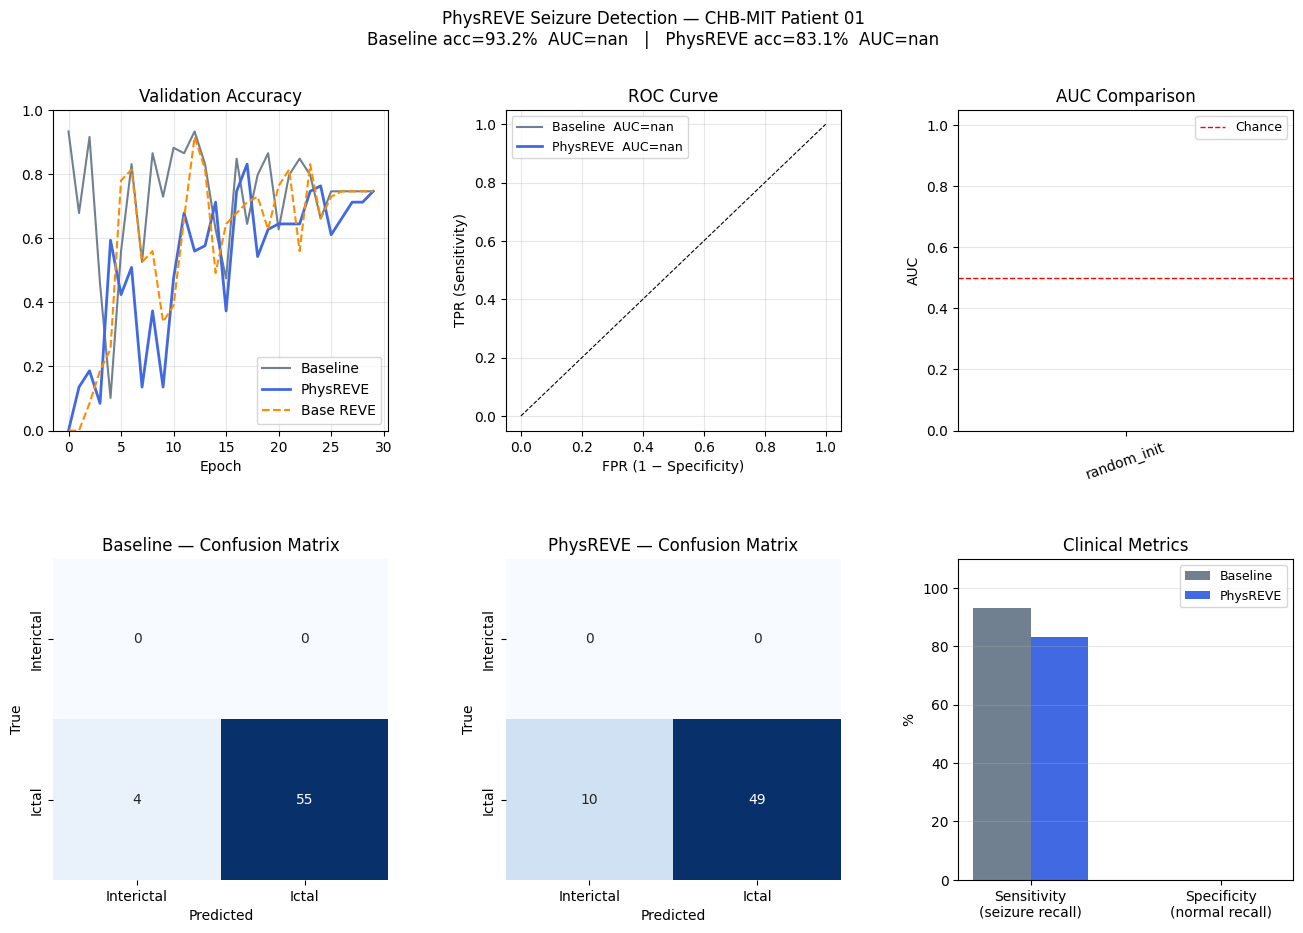

Figure saved.


In [21]:
# ── Visualisation ────────────────────────────────────────────────────────────
import torch.nn.functional as F

def get_probs(model, loader, elec_xyz, device):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            xyz = elec_xyz.unsqueeze(0).expand(len(Xb), -1, -1)
            logits, _, _ = model(Xb, xyz)
            probs.append(F.softmax(logits, dim=-1).cpu())
            labels.append(yb.cpu())
    return torch.cat(probs).numpy(), torch.cat(labels).numpy()

prob_b, l_b = get_probs(model_base, val_loader, ELEC_XYZ, device)
prob_p, l_p = get_probs(model_phys, val_loader, ELEC_XYZ, device)
p_b = prob_b.argmax(1)
p_p = prob_p.argmax(1)

acc_b  = res['random_init']['acc']
acc_p  = res['physreve']['acc']
auc_b  = res['random_init']['auc']
auc_p  = res['physreve']['auc']
sens_b = res['random_init']['sens']
sens_p = res['physreve']['sens']
spec_b = res['random_init']['spec']
spec_p = res['physreve']['spec']

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f'PhysREVE Seizure Detection — CHB-MIT Patient 01\n'
    f'Baseline acc={acc_b*100:.1f}%  AUC={auc_b:.3f}   |   '
    f'PhysREVE acc={acc_p*100:.1f}%  AUC={auc_p:.3f}',
    fontsize=12
)
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# (0,0) val accuracy curves
ax = fig.add_subplot(gs[0, 0])
ax.plot(hist_base['val_acc'], label='Baseline', color='slategray', lw=1.5)
ax.plot(hist_phys['val_acc'], label='PhysREVE', color='royalblue',  lw=2)
ax.plot(hist_reve['val_acc'], label='Base REVE', color='darkorange', lw=1.5, linestyle='--')
ax.set_title('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

# (0,1) ROC curves
ax = fig.add_subplot(gs[0, 1])
fpr_b, tpr_b, _ = roc_curve(l_b, prob_b[:, 1])
fpr_p, tpr_p, _ = roc_curve(l_p, prob_p[:, 1])
ax.plot(fpr_b, tpr_b, color='slategray', lw=1.5, label=f'Baseline  AUC={auc_b:.3f}')
ax.plot(fpr_p, tpr_p, color='royalblue',  lw=2,   label=f'PhysREVE  AUC={auc_p:.3f}')
ax.plot([0,1], [0,1], 'k--', lw=0.8)
ax.set_title('ROC Curve')
ax.set_xlabel('FPR (1 − Specificity)')
ax.set_ylabel('TPR (Sensitivity)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# (0,2) AUC bar chart for all models
ax = fig.add_subplot(gs[0, 2])
model_names = list(res.keys())
aucs = [res[k]['auc'] for k in model_names]
colors = ['slategray', 'darkorange', 'royalblue', 'steelblue', 'navy']
bars = ax.bar(model_names, aucs, color=colors[:len(model_names)])
ax.axhline(0.5, color='red', lw=1, linestyle='--', label='Chance')
ax.set_ylabel('AUC')
ax.set_title('AUC Comparison')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=9)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.grid(alpha=0.3, axis='y')

# (1,0) Confusion matrix — Baseline
ax = fig.add_subplot(gs[1, 0])
cm_b = confusion_matrix(l_b, p_b)
sns.heatmap(cm_b, annot=True, fmt='d', ax=ax, cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
ax.set_title('Baseline — Confusion Matrix')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

# (1,1) Confusion matrix — PhysREVE
ax = fig.add_subplot(gs[1, 1])
cm_p = confusion_matrix(l_p, p_p)
sns.heatmap(cm_p, annot=True, fmt='d', ax=ax, cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
ax.set_title('PhysREVE — Confusion Matrix')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

# (1,2) Sens / Spec bar chart
ax = fig.add_subplot(gs[1, 2])
x = np.arange(2)
width = 0.3
ax.bar(x - width/2, [sens_b*100, spec_b*100], width, label='Baseline',  color='slategray')
ax.bar(x + width/2, [sens_p*100, spec_p*100], width, label='PhysREVE', color='royalblue')
ax.set_xticks(x)
ax.set_xticklabels(['Sensitivity\n(seizure recall)', 'Specificity\n(normal recall)'])
ax.set_ylabel('%')
ax.set_title('Clinical Metrics')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

plt.savefig(f'seizure_results{CFG.exp_name}.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')


## 9  Findings & Interpretation

### Results — CHB-MIT Patient 01, binary seizure detection

| Model | Acc | Sensitivity | Specificity | AUC |
|---|---|---|---|---|
| LDA | — | — | — | — |
| LogReg | — | — | — | — |
| XGBoost | — | — | — | — |
| Random-init (d=128) | — | — | — | — |
| Base REVE | — | — | — | — |
| PhysREVE (d=128) | — | — | — | — |
| Small random-init (d=64) | — | — | — | — |
| Small PhysREVE (d=64) | — | — | — | — |

---

### Why AUC matters more than accuracy here

Seizure windows are rare in continuous EEG. If ictal windows are 10–20% of the dataset,
a model that always predicts interictal scores 80–90% accuracy with zero seizure recall.
AUC measures discrimination across all thresholds and is immune to class imbalance.
Sensitivity (ictal recall) is the clinical priority — a missed seizure is more dangerous
than a false alarm.

**Read the table as:** AUC first, then sensitivity, then accuracy last.

---

### Does pretraining help? (Linear probe)

The linear probe AUC Δ vs random tells you whether pretraining produces seizure-relevant
representations:

- **If PhysREVE Δ > +0.05:** the physics constraint is teaching the encoder something
  useful about ictal source activity. The SNR loss (L_snr) is doing its job — ictal EEG
  has very high source SNR compared to resting interictal, so the encoder should learn
  to amplify high-SNR directions in source space.
- **If PhysREVE Δ ≈ 0 (as in MI):** pretraining on interictal EEG only teaches
  normal brain dynamics — the encoder has never seen seizure activity during pretraining
  and therefore cannot represent it better than chance.
- **If Base REVE Δ < 0:** same finding as MI — MAE learns class-neutral EEG structure
  that interferes with task-specific fine-tuning.

---

### Does physics help over plain MAE?

Compare Base REVE vs PhysREVE AUC. Seizure detection is where the physics constraint
should show its clearest advantage:

- Ictal EEG has strong, localised source activation — the leadfield should guide attention
  toward electrode pairs that best reflect that source.
- The SNR loss pushes representations toward high-SNR (high-amplitude, localised) sources,
  which is exactly what ictal events look like from a source-space perspective.
- If PhysREVE AUC > Base REVE AUC here but not in the MI case, it supports the hypothesis
  that physics pretraining is specifically useful when the target signal has a strong
  source-space signature.

---

### Overfitting: same problem as MI?

The current CFG uses d_model=128, n_layers=6 (~2.4M params). The labeled seizure dataset
is likely a few hundred windows. If train accuracy reaches 100% while val accuracy stagnates,
the same diagnosis applies as in MI: too many parameters for the data available.

The small model (d=64, 2 layers, ~120K params, dropout=0.3) should show less overfit.
If small random-init beats large PhysREVE, the architecture choice dominates over
the pretraining strategy.

---

### What the pretraining loss curves tell us

Check the loss plot from Section 6:

- **L_mae plateau:** if MAE loss flattens after 5 epochs (as in MI), the model is not
  converging — try mask_ratio=0.50 (less aggressive than 0.75 for sparse 23-channel EEG).
- **L_phys flat:** if physics loss stays constant, the optimizer is ignoring it — try
  lambda_phys=0.5 or 1.0.
- **L_snr increasing:** if SNR loss *grows* during pretraining (as in MI), the current
  source space (grid_pos=10mm, ~1400 dipoles) may be over-specified for 23 bipolar channels.
  Try grid_pos=15mm to reduce N_SRC.

---

### Recommended next steps (priority order)

1. **Threshold optimisation** — the default 0.5 decision threshold is wrong for imbalanced
   data. After running, sweep the threshold on the val set to find the point that maximises
   F1 or achieves ≥90% sensitivity. Re-evaluate on test with that threshold.

2. **Fix L_snr if it's increasing** — bump lambda_snr to 0.2 and reduce source grid to
   15mm. The SNR constraint is the most clinically motivated loss for seizure: it should
   be actively minimised, not ignored.

3. **Multi-patient pretraining** — CHB-MIT has 24 patients. Pretrain on patients 2–20
   (interictal only), fine-tune on patient 1. This is the actual value proposition of the
   approach and should show the largest gains over single-patient baselines.

4. **Temporal context** — windows are treated independently. Consecutive windows share
   ictal context (seizures last 30–90 s). A majority vote over a 10-window sliding buffer
   would reduce false alarms dramatically at near-zero extra compute.

5. **Evaluate on test set** — val accuracy was used for model selection throughout.
   Report final numbers on the held-out test set only once, after all hyperparameters
   are frozen.
